# Tuolumne S1-Rc QC Moist Ripe and Drain Test

Per-pixel count of years (2017–2020) each pixel passed S1-VV QC (0–4 years), stratified by elevation and aspect.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import os
import importlib
import sys
import rioxarray as rxr
from pathlib import Path
import xarray as xr
import pandas as pd


# gets rid of a lot of annoying warnings, we know there are NaNs (might want to remove this to double check)
import warnings
warnings.filterwarnings("ignore")


In [2]:
sys.path.insert(1, '../scripts/')

In [3]:
import metadata as metadata


In [4]:
import importlib
importlib.reload(metadata)


<module 'metadata' from '/glade/u/home/rossamower/school/uw/cues_git/cues_sentinel_snowmodel/python/figures/../scripts/metadata.py'>

## Config & geometry

In [5]:
importlib.reload(metadata)
# tuolumne
tuolumne_cfg = metadata.load_yaml(Path(f"../../configs/Tuolumne.yaml"))
# ASO
aso_cfg = metadata.load_yaml(Path(f"../../configs/ASO.yaml"))
_,aso_crs = metadata.get_shapefile_fpath(aso_cfg,"basin_shapefile","USCASJ")


## Helper functions

## Terrain loading

In [6]:
sm_tuolumne_biased_fpath = metadata.get_snowmodel_fpath(tuolumne_cfg, "biased")
sm_tuolumne_corrected_fpath = metadata.get_snowmodel_fpath(tuolumne_cfg, "corrected")

In [7]:
def tif_to_shape(mask_da):
    """
    Converts a boolean xarray to a geopandas shape.
    """
  # Boolean mask (or 0/1 mask)
    mask = mask_da.values.astype(np.uint8)

    # Build affine transform from xarray coordinates
    x = mask_da.x.values
    y = mask_da.y.values

    dx = np.abs(x[1] - x[0])
    dy = np.abs(y[1] - y[0])

    transform = Affine(
        dx, 0, x.min() - dx/2,
        0, -dy, y.max() + dy/2
    )

    # Polygonize
    geoms = [
        shape(geom)
        for geom, value in shapes(mask, mask=mask.astype(bool), transform=transform)
        if value == 1
    ]

    gdf = gpd.GeoDataFrame(
        geometry=geoms,
        crs=mask_da.rio.crs
    )

    # Merge all polygons into one watershed polygon
    gdf = gdf.dissolve()  

    return gdf

In [8]:
from rasterio.features import shapes
from shapely.geometry import shape
from affine import Affine

lyell_water_shed = rxr.open_rasterio('/glade/u/home/rossamower/rmower/aso/data/shape/USCATM/raw/Lyell_Watershed.tif').squeeze(drop = True)

lyell_blw_maclure_gauge_lon_lat = [-119.26180,37.77821]

lyell_gdf_proj = tif_to_shape(lyell_water_shed)


In [9]:
streamflow_lyell_df = pd.read_csv('/glade/u/home/rossamower/rmower/aso/data/streamflow/USCATM/processed/LyellBlwMaclure_streamflow.csv')
streamflow_lyell_df['Date_Time'] = pd.to_datetime(streamflow_lyell_df['Date_Time'])

In [10]:
aso_ds = xr.load_dataset('/glade/u/home/rossamower/rmower/aso/data/aso/USCATM/processed/ASO_50M_SWE_SPATIAL.nc')

In [11]:
ds_ctrl = xr.load_dataset('/glade/campaign/ral/hap/rmower/aso/data/forcing/USCATM_BUFF/wrf_404/CTRL/wrf_ctrl.nc')


In [12]:
def sm_intersect_curvilinear(xlat,xlon,obs_lat,obs_lon):
    """
    Intersects lat and lon location of insitu observation with SnowModel grid
    Input:
      xlat - 2D numpy array representing latitude values for each SnowModel grid
                      point.
      xlon - 2D numpy array representing latitude values for each SnowModel grid
                      point.
      obs_lat - python float of latitude for observation.
      obs_lon - python float of longitude for observation.

    Output:
      idy - integer representing y-index of intersected point on SnowModel grid.
      idx - integer representing x-index of intersected point on SnowModel grid.
    """
    dist = np.sqrt((xlat - obs_lat)**2 + (xlon - obs_lon)**2)
    idy,idx = np.argwhere(dist == np.min(dist))[0]
    return idy,idx
idy_wrf,idx_wrf = sm_intersect_curvilinear(ds_ctrl.XLAT.values,ds_ctrl.XLONG.values,lyell_blw_maclure_gauge_lon_lat[1],lyell_blw_maclure_gauge_lon_lat[0])
idy_wrf,idx_wrf 

(9, 15)

In [13]:
base_dir = '/glade/campaign/ral/hap/rmower/aso/data/forcing/USCATM_BUFF/wrf_404/3_hrly/year/2019/month/'
f_lst = []
for mo in os.listdir(base_dir):
    if (int(mo) > 1) and (int(mo) < 7):
        mo_dir = f'{base_dir}{mo}/'
        f_lst.append(f'{mo_dir}T2.nc')
sorted(f_lst)

['/glade/campaign/ral/hap/rmower/aso/data/forcing/USCATM_BUFF/wrf_404/3_hrly/year/2019/month/02/T2.nc',
 '/glade/campaign/ral/hap/rmower/aso/data/forcing/USCATM_BUFF/wrf_404/3_hrly/year/2019/month/03/T2.nc',
 '/glade/campaign/ral/hap/rmower/aso/data/forcing/USCATM_BUFF/wrf_404/3_hrly/year/2019/month/04/T2.nc',
 '/glade/campaign/ral/hap/rmower/aso/data/forcing/USCATM_BUFF/wrf_404/3_hrly/year/2019/month/05/T2.nc',
 '/glade/campaign/ral/hap/rmower/aso/data/forcing/USCATM_BUFF/wrf_404/3_hrly/year/2019/month/06/T2.nc']

In [14]:
wrf_temp = (xr.open_mfdataset(sorted(f_lst)).isel({"south_north":idy_wrf,"east_west":idx_wrf})['T2']-273.15)
wrf_temp

<xarray.DataArray 'T2' (Time: 1200)> Size: 5kB
dask.array<sub, shape=(1200,), dtype=float32, chunksize=(248,), chunktype=numpy.ndarray>
Coordinates:
  * Time     (Time) datetime64[ns] 10kB 2019-02-01 ... 2019-06-30T21:00:00
    XLAT     float32 4B dask.array<chunksize=(), meta=np.ndarray>
    XLONG    float32 4B dask.array<chunksize=(), meta=np.ndarray>

In [15]:
def match_datasets(ds_s1, ds_sm):
    import numpy as np
    import xarray as xr

    # Use existing y/x coordinates as dimensions
    ds_sm = ds_sm.swap_dims({
        "south_north": "y",
        "east_west": "x"
    })

    # Drop old integer coords
    ds_sm = ds_sm.drop_vars(
        [v for v in ["south_north", "east_west"] if v in ds_sm],
        errors="ignore"
    )

    # Sort into same orientation
    ds_sm = ds_sm.sortby("y").sortby("x")
    ds_s1 = ds_s1.sortby("y").sortby("x")

    # Force SnowModel onto S1 grid
    ds_sm_match = ds_sm.assign_coords(
        x=ds_s1.x,
        y=ds_s1.y
    )

    phase_labels = {0: "dry", 1: "moist", 2: "ripe", 3: "output"}

    def code_to_label(arr):
        out = np.full(arr.shape, "", dtype="<U6")
        for code, label in phase_labels.items():
            out[arr == code] = label
        return out

    ds_sm_match["phase_name"] = xr.apply_ufunc(
        code_to_label,
        ds_sm_match["phase_code"],
        dask="parallelized",
        output_dtypes=["<U6"],
    )

    ds_sm_match, ds_s1_match = xr.align(
        ds_sm_match,
        ds_s1,
        join="inner"
    )

    ds_sm_match["qc_ok"] = ds_s1_match["qc_ok"]

    return ds_sm_match, ds_s1_match

In [16]:
import copy
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_distributed_phase_date(ds: xr.Dataset,
                                date_str: str,
                                ax = None,
                                twoWkAgg: bool = False,
                                clpShape: gpd.GeoDataFrame = None,
                                directMask: bool = True,
                                ):

    # Convert names to plotting codes
    phase_map = {
        "dry": 0,
        "moist": 1,
        "ripe": 2,
        "output": 3,
        "na": -1,
    }

    if twoWkAgg:
        start_date = pd.to_datetime(date_str) - pd.Timedelta(weeks=1)
        end_date   = pd.to_datetime(date_str) + pd.Timedelta(weeks=1)
        phases_window = ds["phase_name"].sel(time=slice(start_date, end_date))

        # Tie-break preference: output > ripe > moist > na > dry (lowest)
        pref_order = ["output", "ripe", "moist", "na", "dry"]
        phase_counts = {p: (phases_window == p).sum(dim="time").values
                        for p in pref_order}
        all_counts = np.stack([phase_counts[p] for p in pref_order], axis=0)
        max_counts = all_counts.max(axis=0)

        # Iterate low-to-high priority so highest priority overwrites ties
        majority_arr = np.full(max_counts.shape, "na", dtype="<U6")
        for p in reversed(pref_order):
            majority_arr[phase_counts[p] == max_counts] = p

        phase_arr_2d = np.vectorize(lambda v: phase_map.get(v, -1))(majority_arr)
        phase_plot = xr.DataArray(phase_arr_2d, dims=["y", "x"],
                                  coords={"y": ds.y, "x": ds.x})
        phase_plot = phase_plot.where(ds.qc_ok, -1)
    else:
        phase_plot = xr.apply_ufunc(
            lambda x: np.vectorize(lambda v: phase_map.get(v, -1))(x),
            ds["phase_name"],
            output_dtypes=[int],
        )
        if directMask:
            phase_plot = phase_plot.where(ds.qc_ok, -1)
        phase_save = copy.deepcopy(phase_plot)
        phase_plot = phase_plot.sel(time=date_str)

    if clpShape is not None:
        phase_plot = phase_plot.rio.clip(clpShape.geometry)
        if directMask == False:
            phase_plot = phase_plot.rio.clip(clpShape.geometry)
        
        phase_plot = phase_plot.where(phase_plot >= -1)


    cmap = ListedColormap([
        "lightgray",      # invalid
        "white",          # dry
        "#AEC7E8", # moist
        "#FFBB78",         # ripe
        "#FF7F0E",             # output
    ])

    norm = BoundaryNorm(
        [-1.5, -0.5, 0.5, 1.5, 2.5, 3.5],
        cmap.N
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(8,8))

    p = (
        phase_plot
        .plot(
            ax=ax,
            cmap=cmap,
            norm=norm,
            add_colorbar=False,
        )
    )
    return p,phase_save.rio.clip(lyell_gdf_proj.geometry)


In [17]:
year = 2019

ds_sm_optimized = xr.load_dataset(
    f'{sm_tuolumne_corrected_fpath}melt_phases/sm_melt_{year}_wt_0_00035.nc'
)

ds_sm_baseline = xr.load_dataset(
    f'{sm_tuolumne_biased_fpath}melt_phases/sm_melt_{year}_wt_0_00035.nc'
)

ds_sm_baseline = ds_sm_baseline.rio.write_crs(aso_crs)
ds_sm_optimized = ds_sm_optimized.rio.write_crs(aso_crs)
# sentinel
ds_s1_vv = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/{year}_wetness_phase.nc")
ds_s1_vv = ds_s1_vv.rio.write_crs(aso_crs)

ds_sm_bl_match_vv,_ = match_datasets(ds_s1_vv,ds_sm_baseline)
ds_sm_op_match_vv,ds_s1_vv_match_vv = match_datasets(ds_s1_vv,ds_sm_optimized)


## Load SnowModel Data
### ROFF

In [18]:
nc_dir = '/glade/campaign/ral/hap/rmower/pixel/snowmodel/tuolumne/outputs/wo_assim/conus_404/ml_corrected/wy_2019/netcdf/'
file_lst = []
for file in os.listdir(nc_dir):
    yr_str = file[-17:-13]
    mo_str = file[-13:-11]
    if 'sm_roff' in file:
        if (yr_str == '2019') and (int(mo_str) > 1):
            file_lst.append(nc_dir + file)


roff_ds = xr.open_mfdataset(sorted(file_lst))
roff_ds.load()

sm_ctrl = xr.load_dataset('/glade/campaign/ral/hap/rmower/pixel/snowmodel/tuolumne/outputs/wo_assim/conus_404/ml_corrected/wy_2019/geography/ctrl_proj.nc')


In [19]:
import numpy as np
import xarray as xr
from shapely.geometry import Point
from shapely.prepared import prep

# --------------------------------------------------
# Attach projected coordinates from control file
# --------------------------------------------------
roff_proj = roff_ds.assign_coords(
    x_utm=(("south_north", "east_west"), sm_ctrl["XLONG"].values),
    y_utm=(("south_north", "east_west"), sm_ctrl["XLAT"].values),
)

lyell_gdf_utm = lyell_gdf_proj.to_crs("EPSG:32611")
lyell_geom = prep(lyell_gdf_utm.geometry.unary_union)

# --------------------------------------------------
# Make 2D basin mask
# --------------------------------------------------
x2d = roff_proj["x_utm"].values
y2d = roff_proj["y_utm"].values

mask = np.zeros(x2d.shape, dtype=bool)

for i in range(x2d.shape[0]):
    for j in range(x2d.shape[1]):
        if np.isfinite(x2d[i, j]) and np.isfinite(y2d[i, j]):
            mask[i, j] = lyell_geom.contains(Point(x2d[i, j], y2d[i, j]))

mask_da = xr.DataArray(
    mask,
    dims=("south_north", "east_west"),
    coords={
        "south_north": roff_proj.south_north,
        "east_west": roff_proj.east_west,
    },
    name="lyell_mask",
)

# --------------------------------------------------
# Apply mask
# --------------------------------------------------
roff_lyell = roff_proj["roff"].where(mask_da)


In [20]:
# Basin-mean runoff depth per SnowModel timestep
# units remain m / 3 hr
roff_basin = roff_lyell.mean(
    dim=("south_north", "east_west"),
    skipna=True
).fillna(0)

roff_basin.name = "basin_mean_roff"
roff_basin.attrs["units"] = "m / 3 hr"

In [21]:
lyell_gdf_utm = lyell_gdf_proj.to_crs("EPSG:32611")
basin_area_m2 = lyell_gdf_utm.geometry.area.sum()

dt_seconds = 3 * 3600

q_in = roff_basin * basin_area_m2 / dt_seconds
q_in.name = "basin_roff_inflow"
q_in.attrs["units"] = "m3 s-1"

print("basin area km2:", basin_area_m2 / 1e6)
print("q_in max:", q_in.max().item())

basin area km2: 15.8325
q_in max: 19.25168228149414


Fixed March baseflow [m3/s]: 0.000
Fixed tau [h]: 48.0
Best scale [-]: 0.79
NSE: 0.95


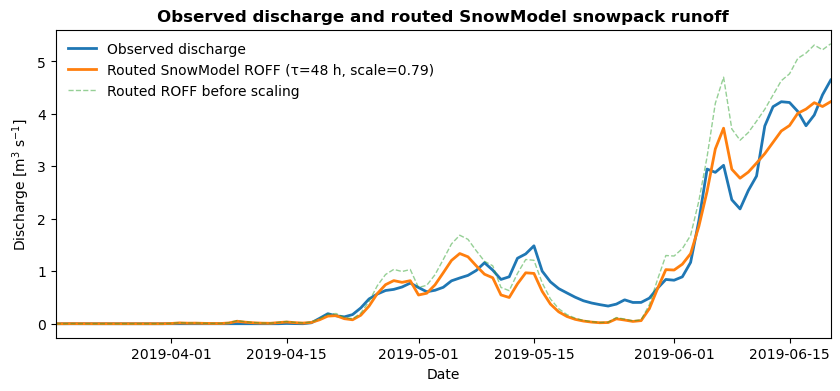

In [22]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ==========================================================
# Inputs assumed available:
# q_in: xarray DataArray, time, m3/s discharge-equivalent SnowModel ROFF
# streamflow_lyell_df: columns Date_Time, Estimated_Discharge
# year
# dt_seconds = 3 * 3600
# ==========================================================

# ----------------------------------------------------------
# Stable linear reservoir
# ----------------------------------------------------------
def route_linear_reservoir(q_in_values, tau_hours, dt_seconds):
    q_in_values = np.asarray(q_in_values, dtype=float)
    q_in_values = np.where(np.isfinite(q_in_values), q_in_values, 0)

    tau_seconds = tau_hours * 3600
    alpha = np.exp(-dt_seconds / tau_seconds)

    q_out = np.zeros_like(q_in_values)

    for t in range(1, len(q_in_values)):
        q_out[t] = alpha * q_out[t - 1] + (1 - alpha) * q_in_values[t]

    return q_out


def nse(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    valid = np.isfinite(obs) & np.isfinite(sim)

    obs = obs[valid]
    sim = sim[valid]

    return 1 - np.sum((obs - sim) ** 2) / np.sum((obs - np.mean(obs)) ** 2)


# ----------------------------------------------------------
# Observed daily discharge
# ----------------------------------------------------------
obs_daily = streamflow_lyell_df[["Date_Time", "Estimated_Discharge"]].copy()
obs_daily["Date_Time"] = pd.to_datetime(obs_daily["Date_Time"])

obs_daily = (
    obs_daily
    .set_index("Date_Time")
    .sort_index()
    .resample("1D")
    .mean()
)

# ----------------------------------------------------------
# Fixed March baseflow from observations
# ----------------------------------------------------------
march_start = pd.to_datetime(f"{year}-03-01")
march_end   = pd.to_datetime(f"{year}-03-31")

baseflow_fixed = float(
    obs_daily.loc[march_start:march_end, "Estimated_Discharge"].median()
)

print(f"Fixed March baseflow [m3/s]: {baseflow_fixed:.3f}")


# ----------------------------------------------------------
# Routing helper returning daily values
# ----------------------------------------------------------
q_time = pd.to_datetime(q_in.time.values)

def routed_daily_for_tau(tau_hours):
    q_route = route_linear_reservoir(q_in.values, tau_hours, dt_seconds)

    q_route_daily = (
        pd.Series(q_route, index=q_time)
        .resample("1D")
        .mean()
    )

    return q_route_daily


# ----------------------------------------------------------
# Calibration period
# ----------------------------------------------------------
cal_start = pd.to_datetime(f"{year}-04-01")
cal_end   = pd.to_datetime(f"{year}-06-20")


# ----------------------------------------------------------
# Choose fixed tau and fit only scale
# ----------------------------------------------------------
tau_fixed = 48  # hours; try 24, 36, 48, 72

def objective_fixed_tau_fixed_baseflow(params):
    log_scale = params[0]
    scale = 10 ** log_scale

    q_route_daily = routed_daily_for_tau(tau_fixed)

    df = pd.DataFrame({
        "obs": obs_daily["Estimated_Discharge"],
        "sim_raw": q_route_daily
    }).loc[cal_start:cal_end].dropna()

    obs = df["obs"].values
    sim = baseflow_fixed + scale * df["sim_raw"].values

    if np.any(sim < 0):
        return 1e9

    return np.mean((obs - sim) ** 2)


res = minimize(
    objective_fixed_tau_fixed_baseflow,
    x0=[np.log10(1)],
    bounds=[(np.log10(0.1), np.log10(5))],
    method="L-BFGS-B"
)

scale_best = 10 ** res.x[0]

print(f"Fixed tau [h]: {tau_fixed:.1f}")
print(f"Best scale [-]: {scale_best:.2f}")

# ----------------------------------------------------------
# Final daily routed simulation
# ----------------------------------------------------------
q_route_daily = routed_daily_for_tau(tau_fixed)
q_sim_daily = baseflow_fixed + scale_best * q_route_daily

comparison = pd.DataFrame({
    "obs": obs_daily["Estimated_Discharge"],
    "sim": q_sim_daily,
    "sim_raw": q_route_daily
}).loc[pd.to_datetime(f"{year}-03-18"):pd.to_datetime(f"{year}-06-20")]

print(f"NSE: {nse(comparison['obs'], comparison['sim']):.2f}")


# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    comparison.index,
    comparison["obs"],
    label="Observed discharge",
    linewidth=2
)

ax.plot(
    comparison.index,
    comparison["sim"],
    label=f"Routed SnowModel ROFF (τ={tau_fixed:.0f} h, scale={scale_best:.2f})",
    linewidth=2
)

ax.plot(
    comparison.index,
    comparison["sim_raw"],
    label="Routed ROFF before scaling",
    linewidth=1,
    linestyle="--",
    alpha=0.5
)

ax.set_xlim(pd.to_datetime(f"{year}-03-18"), pd.to_datetime(f"{year}-06-20"))
ax.set_ylabel(r"Discharge [m$^3$ s$^{-1}$]")
ax.set_xlabel("Date")
ax.set_title(
    "Observed discharge and routed SnowModel snowpack runoff",
    fontweight="bold"
)
ax.legend(frameon=False)

plt.show()

# Figure

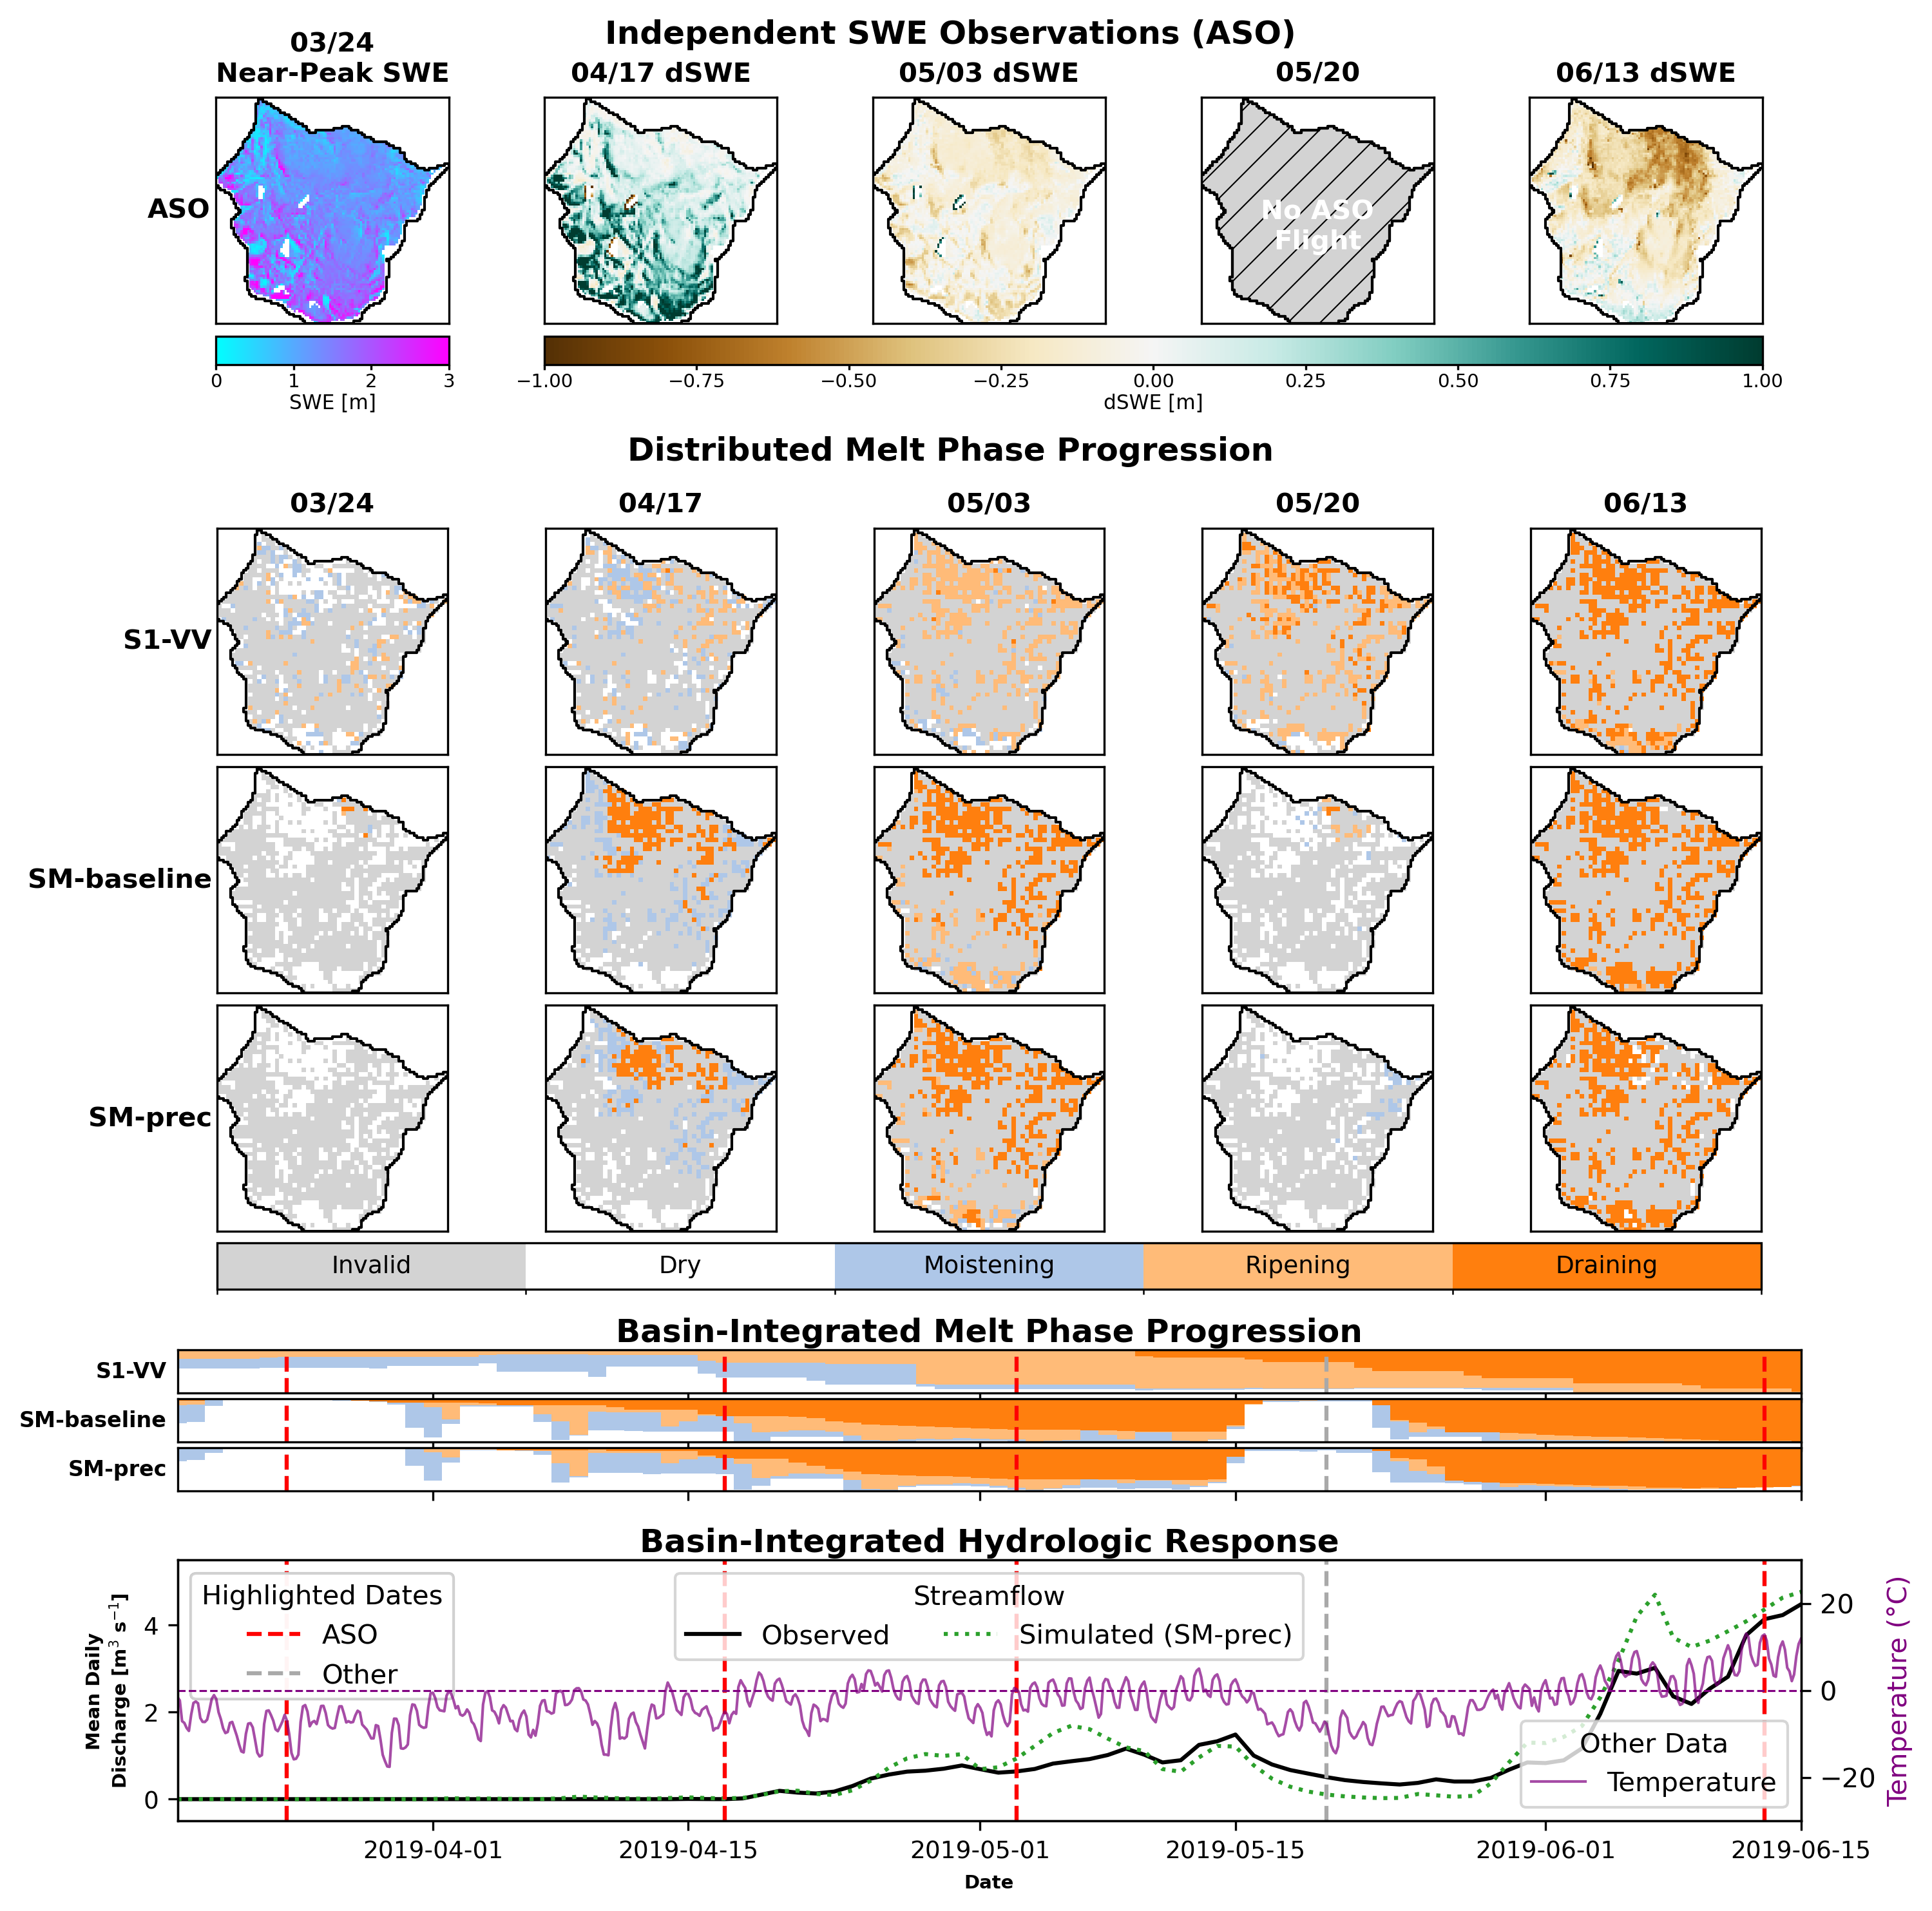

In [23]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================================
# Setup
# ==========================================================
model_lst = [ds_s1_vv_match_vv, ds_sm_bl_match_vv, ds_sm_op_match_vv]
model_names = ["S1-VV", "SM-baseline", "SM-prec"]

stream_slice = streamflow_lyell_df[
    (streamflow_lyell_df.Date_Time >= np.datetime64(f"{year}-03-18")) &
    (streamflow_lyell_df.Date_Time <= np.datetime64(f"{year}-06-15"))
][["Date_Time", "Estimated_Discharge"]].copy()

stream_slice["Date_Time"] = pd.to_datetime(stream_slice["Date_Time"])


x_start = pd.to_datetime(f"{year}-03-18")
x_end   = pd.to_datetime(f"{year}-06-15")

wrf_temp_df = wrf_temp.where(wrf_temp.Time >= x_start,drop = True).where(wrf_temp.Time <= x_end,drop = True).to_dataframe().drop(columns = ['XLAT','XLONG']).reset_index()

aso_basin = (
    aso_ds.where(aso_ds.date.dt.year == year, drop=True)["aso_swe"]
    .rio.write_crs(aso_crs)
    .rio.clip(lyell_gdf_proj.geometry)
)

aso_dates = [str(i)[:10] for i in aso_basin.date.values]
date_lst = aso_dates[:-1]
aso_dates = aso_dates[:-1]
aso_basin = aso_basin.isel(date=slice(0, -1))

# ==========================================================
# Append Dry Date
# ==========================================================
date_lst.append('2019-05-20')
date_lst = sorted(date_lst)
# ==========================================================
# Figure layout
# ==========================================================
fig = plt.figure(
    figsize=(len(date_lst) * 2, 9.8),
    dpi=300
)

gs = fig.add_gridspec(
    nrows=15,
    ncols=len(date_lst),
    height_ratios=[
        0.78,      # ASO
        0.15,     # ASO colorbars -- bigger
        0.50,     # spacer after ASO colorbars
        0.78,      # S1-Rc
        0.005,
        0.78,      # SM-baseline
        0.005,
        0.78,      # SM-prec
        0.20,     # phase colorbar -- bigger
        0.15,     # spacer after phase colorbar
        0.15, 0.15, 0.15,  # phase strips
        0.20,
        0.9
    ],
    hspace=0.05,
    wspace=0.06
)

# ASO axes
aso_ax = np.empty(len(date_lst), dtype=object)
for c in range(len(date_lst)):
    if c == 0:
        aso_ax[c] = fig.add_subplot(gs[0, c])
    else:
        aso_ax[c] = fig.add_subplot(gs[0, c], sharex=aso_ax[0], sharey=aso_ax[0])

# Model axes
model_rows = [3, 5, 7]
ax = np.empty((len(model_lst), len(date_lst)), dtype=object)

for r in range(len(model_lst)):
    for c in range(len(date_lst)):
        if r == 0 and c == 0:
            ax[r, c] = fig.add_subplot(gs[model_rows[r], c])
        else:
            ax[r, c] = fig.add_subplot(
                gs[model_rows[r], c],
                sharex=ax[0, 0],
                sharey=ax[0, 0]
            )

phase_strip_axes = [
    fig.add_subplot(gs[10, :]),
    fig.add_subplot(gs[11, :]),
    fig.add_subplot(gs[12, :]),
]

ax_bottom = fig.add_subplot(gs[14, :])

# ==========================================================
# ASO row
# ==========================================================
a = aso_basin[0].plot(
    ax=aso_ax[0],
    cmap="cool",
    vmin=0,
    vmax=3,
    add_colorbar=False
)

lyell_gdf_proj.plot(ax=aso_ax[0], color="none", edgecolor="black")

# plt.rcParams['hatch.color'] = 'darkgray'
lyell_gdf_proj.plot(ax=aso_ax[-2], color="lightgray", edgecolor="black", hatch = "//")
plt.rcParams['hatch.color'] = 'darkgray'
plt.rcParams['hatch.linewidth'] = 0.5  # Makes hatch lines thinner

aso_ax[0].set_title(
    f"{str(aso_basin.date[0].values)[5:10].replace('-', '/')}\nNear-Peak SWE",
    fontweight="bold"
)

aso_ax[0].set_ylabel("ASO", fontweight="bold",rotation = 0,
                                        ha="right",
                                        va="center",
                                        labelpad=2)

mappable2 = None
for i in range(1, len(aso_dates)):
    if i == len(aso_dates)-1:
        mappable2 = (aso_basin[i] - aso_basin[i - 1]).plot(
            ax=aso_ax[-1],
            cmap="BrBG",
            vmin=-1,
            vmax=1,
            add_colorbar=False
        )
        lyell_gdf_proj.plot(ax=aso_ax[-1], color="none", edgecolor="black")
    else:
        mappable2 = (aso_basin[i] - aso_basin[i - 1]).plot(
            ax=aso_ax[i],
            cmap="BrBG",
            vmin=-1,
            vmax=1,
            add_colorbar=False
        )

    lyell_gdf_proj.plot(ax=aso_ax[i], color="none", edgecolor="black")

    aso_ax[i].set_title(
        f"{str(aso_basin.date[i].values)[5:10].replace('-', '/')} dSWE",
        fontweight="bold"
    )
    aso_ax[i].set_ylabel("")
    
aso_ax[-1].set_title(f"{str(aso_basin.date[i].values)[5:10].replace('-', '/')} dSWE",fontweight = 'bold')
aso_ax[-1].set_xticks([])
aso_ax[-1].set_xlabel("")
aso_ax[-1].set_yticks([])
aso_ax[-1].set_ylabel("")
aso_ax[-2].set_title('05/20',fontweight = 'bold')
aso_ax[-2].text(
    0.5, 0.55,
    "No ASO\nFlight",
    transform=aso_ax[-2].transAxes,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color="white",
)
for aa in aso_ax:
    aa.set_xticks([])
    aa.set_xlabel("")
    aa.set_yticks([])

# ==========================================================
# Model phase maps
# ==========================================================
method_phase_dict = {}

for count, date_str in enumerate(date_lst):
    for model in range(len(model_lst)):

        mappable, phase_save = plot_distributed_phase_date(
            model_lst[model],
            date_str,
            ax[model, count],
            twoWkAgg=False,
            clpShape=lyell_gdf_proj,
            directMask=True,
        )

        if count == 0:
            method_phase_dict[model_names[model]] = phase_save.where(phase_save >= -1)

        lyell_gdf_proj.plot(ax=ax[model, count], color="none", edgecolor="black")

        if model == 0:
            ax[model, count].set_title(
                date_str[5:10].replace("-", "/"),
                fontweight="bold"
            )
        else:
            ax[model, count].set_title("")

        if count == 0:
            ax[model, count].set_ylabel(model_names[model], 
                                        fontweight="bold",
                                        rotation = 0,
                                        ha="right",
                                        va="center",
                                        labelpad=2)
        else:
            ax[model, count].set_ylabel("")

        ax[model, count].set_xticks([])
        ax[model, count].set_xlabel("")
        ax[model, count].set_yticks([])

# ==========================================================
# Streamflow
# ==========================================================

l1 = ax_bottom.plot(
    stream_slice.set_index('Date_Time').resample('1D').mean().reset_index()["Date_Time"],
    stream_slice.set_index('Date_Time').resample('1D').mean().reset_index()["Estimated_Discharge"],
    color="black",
    label="Observed",
    linewidth=1.5,
)
l2 = ax_bottom.plot(
    comparison['sim_raw'],
    color="C2",
    linestyle = ':',
    linewidth = 1.5,
    label='SM-prec\nSimulated',
)
leg1 = ax_bottom.legend(handles= [l1[0],l2[0]],labels = ["Observed",'Simulated (SM-prec)'],title = 'Streamflow',loc = 'upper center',ncol = 2)
ax_bottom.add_artist(leg1)

count = 0
for date_str in date_lst:
    if count == 0:
        l4 = ax_bottom.axvline(pd.to_datetime(date_str), color="darkgray", linestyle="--",label = "Other")
    else:
        ax_bottom.axvline(pd.to_datetime(date_str), color="darkgray", linestyle="--")
    count+=1

for i, aso_date in enumerate(aso_dates):
    l3 = ax_bottom.axvline(
        pd.to_datetime(aso_date),
        color="red",
        linestyle="--",
        label="ASO" if i == 0 else None
    )
leg2 = ax_bottom.legend(handles = [l3,l4],labels = ["ASO","Other"],title='Highlighted Dates')
ax_bottom.add_artist(leg2)


ax_bottom2 = ax_bottom.twinx()
l5 = ax_bottom2.plot(wrf_temp_df.Time,wrf_temp_df.T2,color = 'purple',linewidth = 1,alpha = 0.7)
ax_bottom2.axhline(0,linestyle = '--',color = 'purple',linewidth = 0.75)
ax_bottom2.legend(handles = [l5[0]],labels = ['Temperature'],loc = 'lower right',title = 'Other Data')


ax_bottom2.set_ylim(-30,30)
ax_bottom.set_ylim(-0.5,5.5)
# ==========================================================
# Phase fraction strips
# ==========================================================
phase_codes_bar  = [0, 1, 2, 3]
phase_labels_bar = ["Dry", "Moist", "Ripe", "Output"]

phase_colors_bar = {
    "Dry": "white",
    "Moist": "#AEC7E8",
    "Ripe": "#FFBB78",
    "Output": "#FF7F0E",
}

def calc_phase_frac_no_invalid(phase_da):
    valid = np.isfinite(phase_da) & (phase_da >= 0)

    frac_list = []
    for code in phase_codes_bar:
        frac = (
            ((phase_da == code) & valid).sum(dim=("y", "x"))
            / valid.sum(dim=("y", "x"))
        ) * 100
        frac_list.append(frac)

    return xr.concat(frac_list, dim="phase").assign_coords(phase=phase_labels_bar)

count = 0
for ax_phase, (method_name, phase_da) in zip(phase_strip_axes, method_phase_dict.items()):

    phase_frac = calc_phase_frac_no_invalid(phase_da)
    time_vals = pd.to_datetime(phase_frac.time.values)
    bottom = np.zeros(len(time_vals))

    for phase_name, color in phase_colors_bar.items():
        vals = phase_frac.sel(phase=phase_name).values

        ax_phase.fill_between(
            time_vals,
            bottom,
            bottom + vals,
            color=color,
            step="mid",
            linewidth=0,
        )

        bottom += vals

    ax_phase.set_ylim(0, 100)
    ax_phase.set_yticks([])
    ax_phase.tick_params(axis="x", labelbottom=False)
    ax_phase.set_ylabel(
        method_name,
        rotation=0,
        ha="right",
        va="center",
        fontsize=8,
        fontweight='bold',
    )
    if count == 0:
        pass
        # ax_phase.set_title('Basin phase Evolution', fontweight = 'bold', fontsize = 0,pad=1)

    for date_str in date_lst:
        ax_phase.axvline(pd.to_datetime(date_str), color="darkgray", linestyle="--", linewidth=1.5)

    for aso_date in aso_dates:
        ax_phase.axvline(pd.to_datetime(aso_date), color="red", linestyle="--", linewidth=1.5)
    count += 1

for axx in phase_strip_axes + [ax_bottom, ax_bottom2]:
    axx.set_xlim(x_start, x_end)

# ==========================================================
# Horizontal colorbars aligned to subplot extents
# ==========================================================
fig.subplots_adjust(
    left=0.10,
    right=0.94,
    top=0.965,
    bottom=0.055
)

def add_aligned_cbar(fig, mappable, left_ax, right_ax, gs_slot,
                     orientation="horizontal", label="", height_frac=0.70):
    """
    Create a colorbar axis whose x-extent matches the actual subplot extent
    from left_ax to right_ax, while using gs_slot only for vertical placement.
    """

    # Get horizontal extent from real subplot axes
    left = left_ax.get_position().x0
    right = right_ax.get_position().x1

    # Use temporary GridSpec axis only to get vertical position
    tmp = fig.add_subplot(gs_slot)
    pos = tmp.get_position()
    tmp.remove()

    # Shrink colorbar height within the GridSpec slot
    h = pos.height * height_frac
    y0 = pos.y0 + (pos.height - h) / 2

    cax = fig.add_axes([left, y0, right - left, h])

    cbar = fig.colorbar(
        mappable,
        cax=cax,
        orientation=orientation
    )
    cbar.set_label(label)

    return cbar, cax


# ----------------------------------------------------------
# SWE colorbar: align exactly with first ASO subplot
# ----------------------------------------------------------
cbar_swe, cax_swe = add_aligned_cbar(
    fig=fig,
    mappable=a,
    left_ax=aso_ax[0],
    right_ax=aso_ax[0],
    gs_slot=gs[1, 0],
    label="SWE [m]",
    height_frac=0.65
)

# ----------------------------------------------------------
# dSWE colorbar: align from first dSWE panel to final dSWE panel
# Exclude the SWE panel; include columns 1 through last column.
# ----------------------------------------------------------
cbar_dswe, cax_dswe = add_aligned_cbar(
    fig=fig,
    mappable=mappable2,
    left_ax=aso_ax[1],
    right_ax=aso_ax[-1],
    gs_slot=gs[1, 1:],
    label="dSWE [m]",
    height_frac=0.65
)

# ----------------------------------------------------------
# Melt phase colorbar: align with spatial phase map block
# ----------------------------------------------------------
cbar_phase, cax_phase = add_aligned_cbar(
    fig=fig,
    mappable=mappable,
    left_ax=ax[0, 0],
    right_ax=ax[0, -1],
    gs_slot=gs[8, :],
    label="",
    height_frac=0.8
)

# ----------------------------------------------------------
# Format continuous colorbars
# ----------------------------------------------------------
for cb in [cbar_swe, cbar_dswe]:
    cb.ax.tick_params(labelsize=7, length=2, pad=1)
    cb.ax.xaxis.label.set_size(7.5)
    cb.ax.xaxis.labelpad = 1

# ----------------------------------------------------------
# Format categorical phase colorbar with centered labels
# ----------------------------------------------------------
cbar_phase.set_ticks([])

phase_centers = np.arange(-1, 4)
phase_labels = ["Invalid", "Dry", "Moistening", "Ripening", "Draining"]

for x, lab in zip(phase_centers, phase_labels):
    cbar_phase.ax.text(
        x,
        0.5,
        lab,
        ha="center",
        va="center",
        fontsize=9,
        transform=cbar_phase.ax.transData,
    )

cbar_phase.outline.set_linewidth(0.8)

# ----------------------------------------------------------
# Remaining figure formatting
# ----------------------------------------------------------
phase_strip_axes[0].set_title(
    "Basin-Integrated Melt Phase Progression",
    fontweight="bold",
    pad=3
)

for aa in list(aso_ax.flat) + list(ax.flat):
    aa.title.set_fontsize(10)

ax_bottom.set_title("Basin-Integrated Hydrologic Response", fontweight="bold", pad=3)
ax_bottom.tick_params(labelsize=9)
ax_bottom.set_xlabel("Date", fontsize=7, fontweight="bold")
ax_bottom.set_ylabel(
    "Mean Daily\n"+r"Discharge [m$^3$ s$^{-1}$]",
    fontsize=7,
    fontweight="bold"
)
ax_bottom2.set_ylabel("Temperature (°C)", color="purple")

fig.text(
    0.5,
    0.77,  # tune if needed
    "Distributed Melt Phase Progression",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="bold"
)
fig.text(
    0.5,
    0.99,  # tune if needed
    "Independent SWE Observations (ASO)",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="bold"
)
plt.savefig("./pngs/F08_Lyell_2019_VV.png", dpi=300,bbox_inches="tight",pad_inches=0.1)

plt.show()